# 09 — Secondary k = 3 recurrent-signature feature characterization

**Notebook 9 of 9 — Drosophila book-chapter production pipeline**

**Purpose:** Characterize the strong recurrent core and broader recurrent tier defined by exact signatures from the stability-qualified strict five-stream set.

**Primary inputs:** `data/processed/drosophila_features_reduced.csv`; `data/processed/drosophila_features.csv`; `data/processed/feature_dictionary.csv`; `data/processed/k3_stability_qualified_signature_summary.csv`; `data/processed/k3_cluster_assignments_with_stability_qualified_signatures.csv`; `data/processed/k3_strong_core_signature_cells.csv`; `data/processed/k3_broader_tier_signature_cells.csv`

**Primary outputs:** tier-specific global/posthoc/descriptive CSVs under `data/processed/`; `data/processed/k3_core_vs_broader_agreement_summary.csv`; `data/processed/k3_feature_analysis_summary.csv`; `data/processed/book_chapter_fig5_k3_strong_core_features_source.csv`; `figures/Book_Chapter_Fig_5.png`; `figures/Book_Chapter_Fig_5.tiff`

**Manuscript role:** Secondary k = 3 recurrent-signature results and robustness analysis; produces Book Chapter Figure 5.

**Project authors:** Tim Rogalsky, Nicolas Malagon, Lia Campbell-Enns, Matthaeus Dyck

**Reproducibility:** Designed for fresh-kernel execution in production order 01→09 using repository-relative paths. It consumes explicit feature and stability-qualified membership interfaces written by Notebooks 03, 04, and 07 and requires no private, diagnostic, or obsolete provenance artifact.

The complete six-stream audit contains DW, DK, PH, PK, NH, and NK. The stability-qualified strict five-stream set uses DW, DK, PK, NH, and NK; each exact signature is a literal cross-method assignment pattern, not a biological cell type. The strong recurrent core contains 54 cells in four groups of 16, 14, 13, and 11; the broader recurrent tier contains 81 cells across eight recurrent signatures.

## 1. Environment, paths, and analysis specification

The code declares the package versions, exact feature order, recurrent-tier membership interfaces, significance level, expected signature ranks and sizes, output schemas, and Figure-5 specification. All inputs are current production files written earlier in the 01→09 chain.

In [1]:
from pathlib import Path
import itertools
import platform

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
from PIL import Image
import scipy
from scipy.stats import kruskal, pearsonr, spearmanr
import scikit_posthocs as sp
import statsmodels
from statsmodels.stats.multitest import multipletests

print({
    "Python": platform.python_version(), "numpy": np.__version__,
    "pandas": pd.__version__, "scipy": scipy.__version__,
    "statsmodels": statsmodels.__version__, "scikit-posthocs": sp.__version__,
    "matplotlib": matplotlib.__version__, "Pillow": PIL.__version__,
})

PROCESSED_DIR = Path("data/processed")
FIGURE_DIR = Path("figures")
REDUCED_PATH = PROCESSED_DIR / "drosophila_features_reduced.csv"
ORIGINAL_PATH = PROCESSED_DIR / "drosophila_features.csv"
DICTIONARY_PATH = PROCESSED_DIR / "feature_dictionary.csv"
SUMMARY_PATH = PROCESSED_DIR / "k3_stability_qualified_signature_summary.csv"
ALL_MEMBERSHIP_PATH = PROCESSED_DIR / "k3_cluster_assignments_with_stability_qualified_signatures.csv"
CORE_MEMBERSHIP_PATH = PROCESSED_DIR / "k3_strong_core_signature_cells.csv"
BROAD_MEMBERSHIP_PATH = PROCESSED_DIR / "k3_broader_tier_signature_cells.csv"

CORE_GLOBAL_OUTPUT = PROCESSED_DIR / "k3_strong_core_feature_global_tests.csv"
CORE_POSTHOC_OUTPUT = PROCESSED_DIR / "k3_strong_core_feature_posthoc_tests.csv"
CORE_DESCRIPTIVE_OUTPUT = PROCESSED_DIR / "k3_strong_core_original_scale_descriptives.csv"
BROAD_GLOBAL_OUTPUT = PROCESSED_DIR / "k3_broader_tier_feature_global_tests.csv"
BROAD_POSTHOC_OUTPUT = PROCESSED_DIR / "k3_broader_tier_feature_posthoc_tests.csv"
BROAD_DESCRIPTIVE_OUTPUT = PROCESSED_DIR / "k3_broader_tier_original_scale_descriptives.csv"
COMPARISON_OUTPUT = PROCESSED_DIR / "k3_core_vs_broader_feature_comparison.csv"
AGREEMENT_OUTPUT = PROCESSED_DIR / "k3_core_vs_broader_agreement_summary.csv"
MOVIE_OUTPUT = PROCESSED_DIR / "k3_recurrent_signature_movie_composition.csv"
ANALYSIS_SUMMARY_OUTPUT = PROCESSED_DIR / "k3_feature_analysis_summary.csv"
FIG5_SOURCE_OUTPUT = PROCESSED_DIR / "book_chapter_fig5_k3_strong_core_features_source.csv"
FIG5_PNG = FIGURE_DIR / "Book_Chapter_Fig_5.png"
FIG5_TIFF = FIGURE_DIR / "Book_Chapter_Fig_5.tiff"

ALPHA = 0.05
FEATURE_SCHEMA = [
    "a_mean", "a_std", "a_median", "a_skew", "a_kurtosis",
    "b_dominant_freq", "b_band_power_low", "b_band_power_mid", "b_band_power_high",
    "b_spectral_entropy", "b_spectral_flatness", "c_avg_time_between_peaks",
    "c_std_time_between_peaks", "c_std_time_between_troughs",
    "c_mean_peak_to_trough_time", "c_mean_trough_to_peak_time", "d_slope_magnitude",
    "d_poly_mag_c0", "d_poly_mag_c1", "d_poly_mag_c2", "d_poly_mag_c3",
    "d_poly_peak_c0", "d_poly_peak_c1", "d_poly_peak_c2", "d_poly_peak_c3",
    "d_poly_trough_c0", "d_poly_trough_c1", "d_poly_trough_c2", "d_poly_trough_c3",
    "d_initial_magnitude", "d_final_magnitude",
    "d_initial_peak_to_trough_magnitude", "d_final_peak_to_trough_magnitude",
    "e_autocorr_lag1", "e_autocorr_lagk", "e_hurst_exponent",
    "f_early_mean", "f_late_mean", "f_early_std", "f_late_std",
    "f_early_autocorr", "f_late_autocorr", "f_delta_mean",
    "g_asymmetry_index", "g_sharpness_index",
]
MEMBERSHIP_COLUMNS = [
    "Cell_Name", "K3_DW", "K3_DK", "K3_PH", "K3_PK", "K3_NH", "K3_NK",
    "K3_Strict_Signature", "Signature_Rank", "Signature_N", "Tier",
]
CORE_RANKS = [1, 2, 3, 4]
BROAD_RANKS = list(range(1, 9))
CORE_COUNTS = [16, 14, 13, 11]
BROAD_COUNTS = [16, 14, 13, 11, 8, 7, 7, 5]
CORE_SIGNATURES = [
    "K3-DW2a-DK0-PK1-NH2-NK3",
    "K3-DW1-DK1-PK2-NH1-NK1",
    "K3-DW1-DK1-PK3-NH1-NK1",
    "K3-DW2b-DK0-PK1-NH3-NK2",
]


{'Python': '3.12.10', 'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.15.3', 'statsmodels': '0.14.4', 'scikit-posthocs': '0.11.4', 'matplotlib': '3.10.0', 'Pillow': '12.3.0'}


## 2. Load and validate production inputs

The analysis joins the 108 × 45 reduced feature matrix, the original-scale 55-feature matrix, the feature dictionary, the 31-row exact-signature summary, and current all-cell, strong recurrent core, and broader recurrent tier memberships. Assertions require identical cell identities, exact canonical signatures, 54 core cells, and 81 broader-tier cells.

In [2]:
reduced_raw = pd.read_csv(REDUCED_PATH)
reduced = reduced_raw.rename(columns={reduced_raw.columns[0]: "Cell_Name"}).copy()
original_raw = pd.read_csv(ORIGINAL_PATH)
original = original_raw.rename(columns={original_raw.columns[0]: "Cell_Name"}).copy()
feature_dictionary = pd.read_csv(DICTIONARY_PATH)
signature_summary = pd.read_csv(SUMMARY_PATH, dtype={"K3_DW": str})
all_membership = pd.read_csv(ALL_MEMBERSHIP_PATH, dtype={"K3_DW": str})
core_membership = pd.read_csv(CORE_MEMBERSHIP_PATH, dtype={"K3_DW": str})
broad_membership = pd.read_csv(BROAD_MEMBERSHIP_PATH, dtype={"K3_DW": str})

assert reduced.shape == (108, 46)
assert reduced.columns.tolist() == ["Cell_Name", *FEATURE_SCHEMA]
assert original.shape[0] == 108 and set(FEATURE_SCHEMA) <= set(original.columns)
assert feature_dictionary.columns.tolist() == [
    "Feature_Name", "Feature_Label", "Feature_Description", "Feature_Category"
]
assert feature_dictionary["Feature_Name"].is_unique
assert set(FEATURE_SCHEMA) <= set(feature_dictionary["Feature_Name"])
feature_lookup = feature_dictionary.set_index("Feature_Name")

for table in [reduced, original, all_membership, core_membership, broad_membership]:
    assert table["Cell_Name"].notna().all() and table["Cell_Name"].is_unique
assert reduced["Cell_Name"].tolist() == original["Cell_Name"].tolist() == all_membership["Cell_Name"].tolist()
assert not reduced[FEATURE_SCHEMA].isna().any().any()
assert np.isfinite(reduced[FEATURE_SCHEMA].to_numpy(dtype=float)).all()

assert all_membership.columns.tolist() == MEMBERSHIP_COLUMNS and all_membership.shape == (108, 11)
assert core_membership.columns.tolist() == MEMBERSHIP_COLUMNS and core_membership.shape == (54, 11)
assert broad_membership.columns.tolist() == MEMBERSHIP_COLUMNS and broad_membership.shape == (81, 11)
assert not all_membership.isna().any().any()
assert core_membership["Cell_Name"].tolist() == [
    cell for cell in all_membership["Cell_Name"] if cell in set(core_membership["Cell_Name"])
]
assert broad_membership["Cell_Name"].tolist() == [
    cell for cell in all_membership["Cell_Name"] if cell in set(broad_membership["Cell_Name"])
]
assert set(core_membership["Cell_Name"]) < set(broad_membership["Cell_Name"])
assert core_membership["Signature_Rank"].value_counts().sort_index().tolist() == CORE_COUNTS
assert broad_membership["Signature_Rank"].value_counts().sort_index().tolist() == BROAD_COUNTS
assert signature_summary["Num_Cells"].tolist() == [16, 14, 13, 11, 8, 7, 7, 5, 2, 2, 2, 2, *([1] * 19)]
assert len(signature_summary) == 31 and int(signature_summary["Num_Cells"].eq(1).sum()) == 19
assert signature_summary.iloc[:4]["K3_Strict_Signature"].tolist() == CORE_SIGNATURES
assert signature_summary.iloc[:8]["Rank"].tolist() == BROAD_RANKS
assert signature_summary.iloc[:8]["Num_Cells"].tolist() == BROAD_COUNTS

for row in all_membership.itertuples(index=False):
    expected = f"K3-DW{row.K3_DW}-DK{row.K3_DK}-PK{row.K3_PK}-NH{row.K3_NH}-NK{row.K3_NK}"
    assert row.K3_Strict_Signature == expected

print("Production inputs validated: 108 cells, 45 reduced features, strong core 54, broader tier 81.")
display(signature_summary.head(8))


Production inputs validated: 108 cells, 45 reduced features, strong core 54, broader tier 81.


,Rank,K3_Strict_Signature,K3_DW,K3_DK,K3_PK,K3_NH,K3_NK,Num_Cells,Proportion,Cumulative_Cells,Cumulative_Proportion,Tier
0,1,K3-DW2a-DK0-PK1-NH2-NK3,2a,0,1,2,3,16,0.148148,16,0.148148,Strong core
1,2,K3-DW1-DK1-PK2-NH1-NK1,1,1,2,1,1,14,0.129630,30,0.277778,Strong core
2,3,K3-DW1-DK1-PK3-NH1-NK1,1,1,3,1,1,13,0.120370,43,0.398148,Strong core
3,4,K3-DW2b-DK0-PK1-NH3-NK2,2b,0,1,3,2,11,0.101852,54,0.500000,Strong core
4,5,K3-DW2a-DK0-PK1-NH3-NK2,2a,0,1,3,2,8,0.074074,62,0.574074,Broader tier
5,6,K3-DW2b-DK0-PK1-NH2-NK3,2b,0,1,2,3,7,0.064815,69,0.638889,Broader tier
6,7,K3-DW2b-DK2-PK1-NH2-NK3,2b,2,1,2,3,7,0.064815,76,0.703704,Broader tier
7,8,K3-DW2b-DK2-PK3-NH3-NK2,2b,2,3,3,2,5,0.046296,81,0.750000,Broader tier


## 3. Kruskal–Wallis, rank effect, BH/BY, and Dunn–Holm analysis

Each of the 45 reduced features is tested separately in the strong recurrent core and broader recurrent tier. Rank eta-squared is `max(0, (H - K + 1) / (N - K))`. BH and BY each span all 45 omnibus tests within a tier. Every BH-significant feature receives all within-feature pairwise Dunn comparisons with Holm adjustment and library tie corrections.


In [3]:
def build_analysis(membership):
    analysis = membership[[
        "Cell_Name", "K3_Strict_Signature", "Signature_Rank", "Signature_N", "Tier"
    ]].merge(reduced, on="Cell_Name", how="left", validate="one_to_one")
    assert analysis["Cell_Name"].tolist() == membership["Cell_Name"].tolist()
    assert analysis[["Signature_Rank", *FEATURE_SCHEMA]].notna().all().all()
    assert np.isfinite(analysis[FEATURE_SCHEMA].to_numpy(dtype=float)).all()
    return analysis


def run_global_tests(analysis, ranks, tier):
    n, k = len(analysis), len(ranks)
    rows = []
    for feature_order, feature in enumerate(FEATURE_SCHEMA, start=1):
        arrays = [
            analysis.loc[analysis["Signature_Rank"].eq(rank), feature].to_numpy(dtype=float)
            for rank in ranks
        ]
        result = kruskal(*arrays)
        h_statistic, raw_p = float(result.statistic), float(result.pvalue)
        rows.append({
            "Tier": tier, "Feature_Order": feature_order, "Feature": feature,
            "Feature_Label": feature_lookup.loc[feature, "Feature_Label"],
            "Feature_Category": feature_lookup.loc[feature, "Feature_Category"],
            "N": n, "K_Groups": k, "H_Statistic": h_statistic, "Raw_P": raw_p,
            "Rank_Eta_Squared": max(0.0, (h_statistic - k + 1) / (n - k)),
        })
    frame = pd.DataFrame(rows)
    frame["Raw_P_LT_0_05"] = frame["Raw_P"] < ALPHA
    frame["BH_Significant"], frame["BH_Adjusted_P"], _, _ = multipletests(
        frame["Raw_P"], alpha=ALPHA, method="fdr_bh"
    )
    frame["BY_Significant_Sensitivity"], frame["BY_Adjusted_P"], _, _ = multipletests(
        frame["Raw_P"], alpha=ALPHA, method="fdr_by"
    )
    frame = frame.sort_values(
        ["Rank_Eta_Squared", "Feature"], ascending=[False, True], ignore_index=True
    )
    frame.insert(0, "Effect_Rank", np.arange(1, len(frame) + 1))
    return frame


def significance_stars(p_value):
    return "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""


def run_posthoc(analysis, ranks, global_results):
    signature_by_rank = (
        analysis[["Signature_Rank", "K3_Strict_Signature"]]
        .drop_duplicates().set_index("Signature_Rank")["K3_Strict_Signature"]
    )
    rows = []
    for global_row in global_results.loc[global_results["BH_Significant"]].itertuples(index=False):
        dunn = sp.posthoc_dunn(
            analysis[["Signature_Rank", global_row.Feature]], val_col=global_row.Feature,
            group_col="Signature_Rank", p_adjust="holm",
        ).reindex(index=ranks, columns=ranks)
        for rank_1, rank_2 in itertools.combinations(ranks, 2):
            adjusted_p = float(dunn.loc[rank_1, rank_2])
            rows.append({
                "Tier": global_row.Tier, "Feature": global_row.Feature,
                "Feature_Label": global_row.Feature_Label,
                "Feature_Category": global_row.Feature_Category,
                "Signature_Rank_1": rank_1,
                "K3_Strict_Signature_1": signature_by_rank.loc[rank_1],
                "Signature_Rank_2": rank_2,
                "K3_Strict_Signature_2": signature_by_rank.loc[rank_2],
                "Dunn_Holm_Adjusted_P": adjusted_p,
                "Significant": bool(adjusted_p < ALPHA),
                "Significance_Stars": significance_stars(adjusted_p),
                "H_Statistic": global_row.H_Statistic,
                "Raw_Global_P": global_row.Raw_P,
                "BH_Adjusted_Global_P": global_row.BH_Adjusted_P,
                "Rank_Eta_Squared": global_row.Rank_Eta_Squared,
            })
    return pd.DataFrame(rows).sort_values(
        ["Feature", "Signature_Rank_1", "Signature_Rank_2"], ignore_index=True
    )


core_analysis = build_analysis(core_membership)
broad_analysis = build_analysis(broad_membership)
core_global = run_global_tests(core_analysis, CORE_RANKS, "Strong core")
broad_global = run_global_tests(broad_analysis, BROAD_RANKS, "Broader tier")
core_posthoc = run_posthoc(core_analysis, CORE_RANKS, core_global)
broad_posthoc = run_posthoc(broad_analysis, BROAD_RANKS, broad_global)

def tier_summary(name, global_results, posthoc):
    resolved = posthoc.groupby("Feature")["Significant"].any()
    return {
        "Tier": name, "N_Cells": int(global_results["N"].iloc[0]),
        "K_Groups": int(global_results["K_Groups"].iloc[0]), "Features_Tested": len(global_results),
        "Raw_P_LT_0_05_Features": int(global_results["Raw_P_LT_0_05"].sum()),
        "BH_Q_LT_0_05_Features": int(global_results["BH_Significant"].sum()),
        "BY_Q_LT_0_05_Features": int(global_results["BY_Significant_Sensitivity"].sum()),
        "Posthoc_Contrasts": len(posthoc),
        "Holm_Significant_Contrasts": int(posthoc["Significant"].sum()),
        "BH_Features_With_Any_Holm_Contrast": int(resolved.sum()),
        "Maximum_Rank_Eta_Squared": float(global_results["Rank_Eta_Squared"].max()),
        "Median_Rank_Eta_Squared": float(global_results["Rank_Eta_Squared"].median()),
    }


analysis_summary = pd.DataFrame([
    tier_summary("Strong core", core_global, core_posthoc),
    tier_summary("Broader tier", broad_global, broad_posthoc),
])
expected_summary = {
    "Strong core": [54, 4, 45, 33, 32, 25, 192, 89, 32],
    "Broader tier": [81, 8, 45, 34, 33, 28, 924, 157, 31],
}
summary_columns = [
    "N_Cells", "K_Groups", "Features_Tested", "Raw_P_LT_0_05_Features",
    "BH_Q_LT_0_05_Features", "BY_Q_LT_0_05_Features", "Posthoc_Contrasts",
    "Holm_Significant_Contrasts", "BH_Features_With_Any_Holm_Contrast",
]
for row in analysis_summary.itertuples(index=False):
    assert [getattr(row, column) for column in summary_columns] == expected_summary[row.Tier]
np.testing.assert_allclose(
    analysis_summary["Maximum_Rank_Eta_Squared"], [0.8340041067417756, 0.9161535555633634],
    rtol=0, atol=1e-12,
)
np.testing.assert_allclose(
    analysis_summary["Median_Rank_Eta_Squared"], [0.27539647637945636, 0.28719603880486544],
    rtol=0, atol=1e-12,
)

broad_resolved = broad_posthoc.groupby("Feature")["Significant"].any()
broad_unresolved = broad_global.loc[
    broad_global["BH_Significant"] & ~broad_global["Feature"].isin(broad_resolved[broad_resolved].index),
    ["Feature", "Feature_Label"],
]
assert broad_unresolved["Feature"].tolist() == [
    "b_spectral_entropy", "c_mean_trough_to_peak_time"
]
display(analysis_summary)
display(core_global.head(10))
display(broad_global.head(10))
display(broad_unresolved)


,Tier,N_Cells,K_Groups,Features_Tested,Raw_P_LT_0_05_Features,BH_Q_LT_0_05_Features,BY_Q_LT_0_05_Features,Posthoc_Contrasts,Holm_Significant_Contrasts,BH_Features_With_Any_Holm_Contrast,Maximum_Rank_Eta_Squared,Median_Rank_Eta_Squared
0,Strong core,54,4,45,33,32,25,192,89,32,0.834004,0.275396
1,Broader tier,81,8,45,34,33,28,924,157,31,0.916154,0.287196


,Effect_Rank,Tier,Feature_Order,Feature,Feature_Label,Feature_Category,N,K_Groups,H_Statistic,Raw_P,Rank_Eta_Squared,Raw_P_LT_0_05,BH_Significant,BH_Adjusted_P,BY_Significant_Sensitivity,BY_Adjusted_P
0,1,Strong core,2,a_std,Standard deviation,Statistical Summary,54,4,44.700205,1.071464e-09,0.834004,True,True,1.840704e-08,True,8.089798e-08
1,2,Strong core,45,g_sharpness_index,Sharpness index,Oscillation Shape,54,4,44.084235,1.448265e-09,0.821685,True,True,1.840704e-08,True,8.089798e-08
2,3,Strong core,32,d_initial_peak_to_trough_magnitude,Initial fall amplitude,Magnitude Change,54,4,43.757302,1.699390e-09,0.815146,True,True,1.840704e-08,True,8.089798e-08
3,4,Strong core,30,d_initial_magnitude,Initial oscillation strength,Magnitude Change,54,4,43.540372,1.889584e-09,0.810807,True,True,1.840704e-08,True,8.089798e-08
4,5,Strong core,39,f_early_std,Early standard deviation,Early vs. Late Behavior,54,4,43.378504,2.045226e-09,0.807570,True,True,1.840704e-08,True,8.089798e-08
5,6,Strong core,9,b_band_power_high,High-frequency band power,Oscillation,54,4,42.454186,3.213524e-09,0.789084,True,True,2.410143e-08,True,1.059245e-07
6,7,Strong core,17,d_slope_magnitude,Slope of oscillation magnitude,Magnitude Change,54,4,38.571157,2.139450e-08,0.711423,True,True,1.375361e-07,True,6.044639e-07
7,8,Strong core,8,b_band_power_mid,Mid-frequency band power,Oscillation,54,4,37.780917,3.145026e-08,0.695618,True,True,1.769077e-07,True,7.775003e-07
8,9,Strong core,40,f_late_std,Late standard deviation,Early vs. Late Behavior,54,4,34.652432,1.442639e-07,0.633049,True,True,7.213193e-07,True,3.170161e-06
9,10,Strong core,33,d_final_peak_to_trough_magnitude,Final fall amplitude,Magnitude Change,54,4,31.748330,5.913206e-07,0.574967,True,True,2.660943e-06,True,1.169470e-05


,Effect_Rank,Tier,Feature_Order,Feature,Feature_Label,Feature_Category,N,K_Groups,H_Statistic,Raw_P,Rank_Eta_Squared,Raw_P_LT_0_05,BH_Significant,BH_Adjusted_P,BY_Significant_Sensitivity,BY_Adjusted_P
0,1,Broader tier,2,a_std,Standard deviation,Statistical Summary,81,8,73.879210,2.421361e-13,0.916154,True,True,1.089612e-11,True,4.788790e-11
1,2,Broader tier,45,g_sharpness_index,Sharpness index,Oscillation Shape,81,8,71.242297,8.285099e-13,0.880031,True,True,1.827059e-11,True,8.029830e-11
2,3,Broader tier,39,f_early_std,Early standard deviation,Early vs. Late Behavior,81,8,70.414813,1.218039e-12,0.868696,True,True,1.827059e-11,True,8.029830e-11
3,4,Broader tier,32,d_initial_peak_to_trough_magnitude,Initial fall amplitude,Magnitude Change,81,8,64.067155,2.315047e-11,0.781742,True,True,2.439382e-10,True,1.072096e-09
4,5,Broader tier,9,b_band_power_high,High-frequency band power,Oscillation,81,8,63.725952,2.710424e-11,0.777068,True,True,2.439382e-10,True,1.072096e-09
5,6,Broader tier,30,d_initial_magnitude,Initial oscillation strength,Magnitude Change,81,8,60.735185,1.076426e-10,0.736098,True,True,8.073197e-10,True,3.548128e-09
6,7,Broader tier,17,d_slope_magnitude,Slope of oscillation magnitude,Magnitude Change,81,8,51.670850,6.778843e-09,0.611929,True,True,4.357827e-08,True,1.915242e-07
7,8,Broader tier,8,b_band_power_mid,Mid-frequency band power,Oscillation,81,8,49.089103,2.179557e-08,0.576563,True,True,1.226001e-07,True,5.388209e-07
8,9,Broader tier,40,f_late_std,Late standard deviation,Early vs. Late Behavior,81,8,46.129607,8.248701e-08,0.536022,True,True,4.067507e-07,True,1.787648e-06
9,10,Broader tier,33,d_final_peak_to_trough_magnitude,Final fall amplitude,Magnitude Change,81,8,45.913736,9.086436e-08,0.533065,True,True,4.067507e-07,True,1.787648e-06


,Feature,Feature_Label
27,b_spectral_entropy,Normalized spectral entropy
28,c_mean_trough_to_peak_time,Mean rise time


## 4. Strong recurrent core versus broader recurrent tier

Feature-effect rankings and rank eta-squared values are compared across tiers with Spearman and Pearson correlations and top-5, top-10, and top-15 overlap. The broader recurrent tier is a robustness expansion of the core, not an independent validation dataset.

In [4]:
comparison = core_global[[
    "Feature", "Feature_Label", "Feature_Category", "Effect_Rank", "Rank_Eta_Squared",
    "Raw_P", "BH_Adjusted_P", "BH_Significant", "BY_Adjusted_P", "BY_Significant_Sensitivity",
]].merge(
    broad_global[[
        "Feature", "Effect_Rank", "Rank_Eta_Squared", "Raw_P", "BH_Adjusted_P",
        "BH_Significant", "BY_Adjusted_P", "BY_Significant_Sensitivity",
    ]],
    on="Feature", validate="one_to_one", suffixes=("_Strong_Core", "_Broader_Tier"),
)
comparison["Mean_Effect_Rank"] = comparison[[
    "Effect_Rank_Strong_Core", "Effect_Rank_Broader_Tier"
]].mean(axis=1)
comparison["Effect_Difference_Broader_Minus_Core"] = (
    comparison["Rank_Eta_Squared_Broader_Tier"] - comparison["Rank_Eta_Squared_Strong_Core"]
)
comparison["Rank_Change_Broader_Minus_Core"] = (
    comparison["Effect_Rank_Broader_Tier"] - comparison["Effect_Rank_Strong_Core"]
)
for threshold in [5, 10, 15]:
    comparison[f"Top_{threshold}_Strong_Core"] = comparison["Effect_Rank_Strong_Core"].le(threshold)
    comparison[f"Top_{threshold}_Broader_Tier"] = comparison["Effect_Rank_Broader_Tier"].le(threshold)
    comparison[f"Top_{threshold}_Both"] = (
        comparison[f"Top_{threshold}_Strong_Core"] & comparison[f"Top_{threshold}_Broader_Tier"]
    )
comparison = comparison.sort_values(["Mean_Effect_Rank", "Feature"], ignore_index=True)

spearman = spearmanr(
    comparison["Rank_Eta_Squared_Strong_Core"], comparison["Rank_Eta_Squared_Broader_Tier"]
)
pearson = pearsonr(
    comparison["Rank_Eta_Squared_Strong_Core"], comparison["Rank_Eta_Squared_Broader_Tier"]
)
overlaps = {}
for threshold in [5, 10, 15]:
    core_top = set(comparison.nsmallest(threshold, "Effect_Rank_Strong_Core")["Feature"])
    broad_top = set(comparison.nsmallest(threshold, "Effect_Rank_Broader_Tier")["Feature"])
    overlaps[threshold] = len(core_top & broad_top)
agreement_summary = pd.DataFrame([{
    "Spearman_Effect_Rank_Rho": float(spearman.statistic),
    "Spearman_P": float(spearman.pvalue),
    "Pearson_Effect_Value_R": float(pearson.statistic),
    "Pearson_P": float(pearson.pvalue),
    "Top5_Overlap": overlaps[5], "Top10_Overlap": overlaps[10], "Top15_Overlap": overlaps[15],
}])
np.testing.assert_allclose(
    agreement_summary[["Spearman_Effect_Rank_Rho", "Pearson_Effect_Value_R"]],
    [[0.9728554571216789, 0.9803295948184189]], rtol=0, atol=1e-12,
)
assert [overlaps[5], overlaps[10], overlaps[15]] == [4, 10, 14]
display(agreement_summary)


,Spearman_Effect_Rank_Rho,Spearman_P,Pearson_Effect_Value_R,Pearson_P,Top5_Overlap,Top10_Overlap,Top15_Overlap
0,0.972855,5.791766e-29,0.98033,6.134236e-32,4,10,14


## 5. Original-scale descriptives and movie composition

Original-scale values are used for reader-facing summaries and plotting only. Movie composition is reported for all eight recurrent exact signatures; it is descriptive and does not support specimen-level population inference.


In [5]:
def original_descriptives(membership, tier, ranks):
    analysis = membership[[
        "Cell_Name", "K3_Strict_Signature", "Signature_Rank", "Signature_N"
    ]].merge(original[["Cell_Name", *FEATURE_SCHEMA]], on="Cell_Name", validate="one_to_one")
    assert analysis[["Signature_Rank", *FEATURE_SCHEMA]].notna().all().all()
    assert np.isfinite(analysis[FEATURE_SCHEMA].to_numpy(dtype=float)).all()
    rows = []
    for feature in FEATURE_SCHEMA:
        for rank in ranks:
            selected = analysis.loc[analysis["Signature_Rank"].eq(rank)]
            values = selected[feature].to_numpy(dtype=float)
            q1, median, q3 = np.quantile(values, [0.25, 0.50, 0.75])
            rows.append({
                "Tier": tier, "Feature": feature,
                "Feature_Label": feature_lookup.loc[feature, "Feature_Label"],
                "Feature_Category": feature_lookup.loc[feature, "Feature_Category"],
                "K3_Strict_Signature": selected["K3_Strict_Signature"].iloc[0],
                "Signature_Rank": rank, "Signature_N": int(selected["Signature_N"].iloc[0]),
                "n": len(values), "Median": median, "Q1": q1, "Q3": q3, "IQR": q3 - q1,
            })
    return analysis, pd.DataFrame(rows)


core_original, core_descriptives = original_descriptives(core_membership, "Strong core", CORE_RANKS)
broad_original, broad_descriptives = original_descriptives(broad_membership, "Broader tier", BROAD_RANKS)
assert core_descriptives.shape == (180, 12) and broad_descriptives.shape == (360, 12)
assert core_descriptives.groupby("Feature")["n"].apply(list).apply(lambda x: x == CORE_COUNTS).all()
assert broad_descriptives.groupby("Feature")["n"].apply(list).apply(lambda x: x == BROAD_COUNTS).all()

movie_membership = broad_membership.copy()
movie_membership["Movie"] = movie_membership["Cell_Name"].str.extract(r"^(Mov\. [123])", expand=False)
assert movie_membership["Movie"].notna().all()
movie_rows = []
for rank in BROAD_RANKS:
    members = movie_membership.loc[movie_membership["Signature_Rank"].eq(rank)]
    counts = members["Movie"].value_counts().reindex(["Mov. 1", "Mov. 2", "Mov. 3"], fill_value=0)
    n = len(members)
    movie_rows.append({
        "K3_Strict_Signature": members["K3_Strict_Signature"].iloc[0],
        "Signature_Rank": rank, "Signature_N": n,
        "Movie_1_N": int(counts["Mov. 1"]), "Movie_2_N": int(counts["Mov. 2"]),
        "Movie_3_N": int(counts["Mov. 3"]),
        "Largest_Movie_Fraction": float(counts.max() / n),
        "Only_One_Movie_Represented": bool(counts.gt(0).sum() == 1),
        "Any_Movie_Fewer_Than_3": bool(counts.lt(3).any()),
        "Any_Movie_Absent": bool(counts.eq(0).any()),
        "Movies_Fewer_Than_3": ";".join(movie for movie, count in counts.items() if count < 3),
        "Movies_Absent": ";".join(movie for movie, count in counts.items() if count == 0),
    })
movie_composition = pd.DataFrame(movie_rows)
assert not movie_composition["Only_One_Movie_Represented"].any()
assert not movie_composition["Largest_Movie_Fraction"].ge(0.80).any()
assert movie_composition["Any_Movie_Fewer_Than_3"].all()
assert movie_composition.loc[movie_composition["Any_Movie_Absent"], "Signature_Rank"].tolist() == [1, 5, 6, 8]
display(movie_composition)


,K3_Strict_Signature,Signature_Rank,Signature_N,Movie_1_N,Movie_2_N,Movie_3_N,Largest_Movie_Fraction,Only_One_Movie_Represented,Any_Movie_Fewer_Than_3,Any_Movie_Absent,Movies_Fewer_Than_3,Movies_Absent
0,K3-DW2a-DK0-PK1-NH2-NK3,1,16,10,6,0,0.625000,False,True,True,Mov. 3,Mov. 3
1,K3-DW1-DK1-PK2-NH1-NK1,2,14,1,4,9,0.642857,False,True,False,Mov. 1,
2,K3-DW1-DK1-PK3-NH1-NK1,3,13,1,2,10,0.769231,False,True,False,Mov. 1;Mov. 2,
3,K3-DW2b-DK0-PK1-NH3-NK2,4,11,5,2,4,0.454545,False,True,False,Mov. 2,
4,K3-DW2a-DK0-PK1-NH3-NK2,5,8,5,3,0,0.625000,False,True,True,Mov. 3,Mov. 3
5,K3-DW2b-DK0-PK1-NH2-NK3,6,7,0,2,5,0.714286,False,True,True,Mov. 1;Mov. 2,Mov. 1
6,K3-DW2b-DK2-PK1-NH2-NK3,7,7,1,1,5,0.714286,False,True,False,Mov. 1;Mov. 2,
7,K3-DW2b-DK2-PK3-NH3-NK2,8,5,0,3,2,0.600000,False,True,True,Mov. 1;Mov. 3,Mov. 1


## 6. Book Chapter Figure 5

Figure 5 shows the 54-cell strong recurrent core as display groups A–D in exact-signature recurrence-rank order, with group sizes 16/14/13/11. The fixed 2 × 3 panel order is:

1. `a_std` — standard deviation
2. `g_sharpness_index` — sharpness index
3. `d_initial_peak_to_trough_magnitude` — initial fall amplitude
4. `d_slope_magnitude` — slope of oscillation magnitude
5. `b_band_power_high` — high-frequency band power
6. `c_avg_time_between_peaks` — average time between peaks

The figure preserves all 54 observations per panel, boxplots, deterministic group mapping, and grayscale-readable outlines. The 324-row source table, PNG, and LZW-compressed TIFF are written as production outputs.


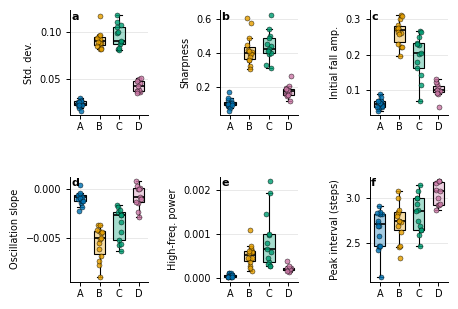

{'pixels': (2764, 1991), 'png_dpi': (599.9988, 599.9988), 'tiff_dpi': (600.0, 600.0), 'tiff_compression': 'tiff_lzw'}


In [6]:
FIG5_EXPECTED_SIZES = [16, 14, 13, 11]
FIG5_CATEGORY_LABELS = ["A", "B", "C", "D"]
FIG5_Y_TICKS = {
    "a": [0.0, 0.05, 0.10, 0.15],
    "b": [0.0, 0.2, 0.4, 0.6, 0.8],
    "c": [0.0, 0.1, 0.2, 0.3, 0.4],
    "d": [-0.010, -0.005, 0.000, 0.005],
    "e": [-0.001, 0.000, 0.001, 0.002, 0.003],
    "f": [2.0, 2.5, 3.0, 3.5],
}
fig5_feature_spec = [
    ("a", "a_std", "Standard deviation", "Std. dev."),
    ("b", "g_sharpness_index", "Sharpness index", "Sharpness"),
    ("c", "d_initial_peak_to_trough_magnitude", "Initial fall amplitude", "Initial fall amp."),
    ("d", "d_slope_magnitude", "Slope of oscillation magnitude", "Oscillation slope"),
    ("e", "b_band_power_high", "High-frequency band power", "High-freq. power"),
    ("f", "c_avg_time_between_peaks", "Average time between peaks", "Peak interval (steps)"),
]
fig5_feature_columns = [source for _, source, _, _ in fig5_feature_spec]
for _, source, label, _ in fig5_feature_spec:
    assert feature_lookup.loc[source, "Feature_Label"] == label
assert "time steps" in feature_lookup.loc[
    "c_avg_time_between_peaks", "Feature_Description"
].lower()

fig5_membership = core_membership[[
    "Cell_Name", "K3_Strict_Signature", "Signature_Rank", "Signature_N"
]].sort_values(["Signature_Rank", "Cell_Name"], ignore_index=True)
fig5_membership["Display_Group"] = fig5_membership["Signature_Rank"].map(
    dict(zip(CORE_RANKS, FIG5_CATEGORY_LABELS))
)
assert fig5_membership.groupby("Signature_Rank")["Cell_Name"].nunique().tolist() == FIG5_EXPECTED_SIZES
assert len(fig5_membership) == fig5_membership["Cell_Name"].nunique() == 54

fig5_wide = fig5_membership.merge(
    original[["Cell_Name", *fig5_feature_columns]], on="Cell_Name", how="left", validate="one_to_one"
)
numeric_values = fig5_wide[fig5_feature_columns].apply(pd.to_numeric, errors="coerce")
assert numeric_values.notna().all().all() and np.isfinite(numeric_values.to_numpy()).all()
fig5_wide.loc[:, fig5_feature_columns] = numeric_values

fig5_rows = []
for panel_order, (panel_letter, source_column, reader_label, _) in enumerate(fig5_feature_spec, start=1):
    for member in fig5_wide.itertuples(index=False):
        fig5_rows.append({
            "Cell_Name": member.Cell_Name,
            "K3_Strict_Signature": member.K3_Strict_Signature,
            "Signature_Rank": int(member.Signature_Rank),
            "Display_Group": member.Display_Group,
            "Group_Size": int(member.Signature_N),
            "Panel_Order": panel_order,
            "Panel_Letter": panel_letter,
            "Source_Feature_Column": source_column,
            "Reader_Facing_Feature_Label": reader_label,
            "Original_Scale_Feature_Value": float(getattr(member, source_column)),
        })
fig5_source = pd.DataFrame(fig5_rows).sort_values(
    ["Panel_Order", "Signature_Rank", "Cell_Name"], ignore_index=True
)
assert fig5_source.shape == (324, 10)
assert fig5_source.groupby("Panel_Letter").size().tolist() == [54] * 6
assert fig5_source.groupby(["Source_Feature_Column", "Cell_Name"]).size().eq(1).all()
assert fig5_source.groupby("Display_Group")["Cell_Name"].nunique().tolist() == FIG5_EXPECTED_SIZES

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
fig5_source.to_csv(FIG5_SOURCE_OUTPUT, index=False)

fig5_palette = ["#0072B2", "#E69F00", "#009E73", "#CC79A7"]
FIG_DPI = 600
FIG_FONT_PT = 7
FIG_PANEL_PT = 8
FIG5_WIDTH_PX = 2764
FIG5_HEIGHT_PX = 1991
fig, axes = plt.subplots(
    2, 3, figsize=(FIG5_WIDTH_PX / FIG_DPI, FIG5_HEIGHT_PX / FIG_DPI), facecolor="white"
)
jitter_rng = np.random.default_rng(20260827)
for ax, (panel_letter, source_column, _, axis_label) in zip(axes.flat, fig5_feature_spec):
    panel = fig5_source.loc[fig5_source["Source_Feature_Column"].eq(source_column)]
    group_values = [
        panel.loc[panel["Signature_Rank"].eq(rank), "Original_Scale_Feature_Value"].to_numpy()
        for rank in CORE_RANKS
    ]
    artists = ax.boxplot(
        group_values, tick_labels=FIG5_CATEGORY_LABELS, widths=0.58,
        patch_artist=True, showfliers=False,
        boxprops={"edgecolor": "black", "linewidth": 0.8},
        medianprops={"color": "black", "linewidth": 1.2},
        whiskerprops={"color": "black", "linewidth": 0.8},
        capprops={"color": "black", "linewidth": 0.8},
    )
    for patch, color in zip(artists["boxes"], fig5_palette):
        patch.set_facecolor(matplotlib.colors.to_rgba(color, 0.35))
    for group_index, (values, color) in enumerate(zip(group_values, fig5_palette), start=1):
        jitter = jitter_rng.uniform(-0.13, 0.13, len(values))
        ax.scatter(
            group_index + jitter, values, s=13, facecolor=color, edgecolor="black",
            linewidth=0.35, alpha=0.82, zorder=3,
        )
    ax.set_ylabel(axis_label, fontsize=FIG_FONT_PT, labelpad=4)
    ax.yaxis.set_major_locator(matplotlib.ticker.FixedLocator(FIG5_Y_TICKS[panel_letter]))
    ax.tick_params(axis="y", labelsize=FIG_FONT_PT, width=0.7, length=3)
    ax.tick_params(axis="x", labelsize=FIG_FONT_PT, width=0.7, length=3, pad=2)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
    ax.grid(axis="y", color="0.88", linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_linewidth(0.7)
    ax.text(
        0.015, 0.985, panel_letter, transform=ax.transAxes, fontsize=FIG_PANEL_PT,
        fontweight="bold", ha="left", va="top",
    )
fig.subplots_adjust(left=0.17, right=0.99, bottom=0.15, top=0.97, wspace=0.92, hspace=0.58)
fig.savefig(FIG5_PNG, dpi=FIG_DPI, facecolor="white")
fig.savefig(FIG5_TIFF, dpi=FIG_DPI, facecolor="white", pil_kwargs={"compression": "tiff_lzw"})
with Image.open(FIG5_PNG) as png_image:
    png_size, png_dpi = png_image.size, png_image.info.get("dpi")
with Image.open(FIG5_TIFF) as tiff_image:
    tiff_size, tiff_dpi = tiff_image.size, tiff_image.info.get("dpi")
    tiff_compression = tiff_image.info.get("compression")
assert png_size == tiff_size == (FIG5_WIDTH_PX, FIG5_HEIGHT_PX)
assert png_dpi and all(abs(value - FIG_DPI) < 0.1 for value in png_dpi)
assert tiff_dpi and all(abs(value - FIG_DPI) < 0.1 for value in tiff_dpi)
assert str(tiff_compression).lower() in {"tiff_lzw", "lzw"}
plt.show()
print({"pixels": png_size, "png_dpi": png_dpi, "tiff_dpi": tiff_dpi, "tiff_compression": tiff_compression})


## 7. Validation and outputs

The notebook writes tier-specific omnibus tests, Dunn–Holm contrasts, original-scale descriptives, core-versus-broader comparisons, movie composition, a compact analysis summary, the 324-row Figure-5 source table, and the 600-dpi Figure-5 files. Final assertions verify every output schema and the accepted inferential counts.

In [7]:
exports = {
    CORE_GLOBAL_OUTPUT: core_global,
    CORE_POSTHOC_OUTPUT: core_posthoc,
    CORE_DESCRIPTIVE_OUTPUT: core_descriptives,
    BROAD_GLOBAL_OUTPUT: broad_global,
    BROAD_POSTHOC_OUTPUT: broad_posthoc,
    BROAD_DESCRIPTIVE_OUTPUT: broad_descriptives,
    COMPARISON_OUTPUT: comparison,
    AGREEMENT_OUTPUT: agreement_summary,
    MOVIE_OUTPUT: movie_composition,
    ANALYSIS_SUMMARY_OUTPUT: analysis_summary,
}
for path, frame in exports.items():
    frame.to_csv(path, index=False)

expected_shapes = {
    CORE_GLOBAL_OUTPUT: (45, 16), CORE_POSTHOC_OUTPUT: (192, 15),
    CORE_DESCRIPTIVE_OUTPUT: (180, 12), BROAD_GLOBAL_OUTPUT: (45, 16),
    BROAD_POSTHOC_OUTPUT: (924, 15), BROAD_DESCRIPTIVE_OUTPUT: (360, 12),
    COMPARISON_OUTPUT: (45, 29), AGREEMENT_OUTPUT: (1, 7),
    MOVIE_OUTPUT: (8, 12), ANALYSIS_SUMMARY_OUTPUT: (2, 12),
    FIG5_SOURCE_OUTPUT: (324, 10),
}
for path, expected_shape in expected_shapes.items():
    exported = pd.read_csv(path)
    assert exported.shape == expected_shape, (path, exported.shape, expected_shape)
    assert path.stat().st_size > 0
    print(f"{path}: {exported.shape[0]} x {exported.shape[1]}")

assert [len(core_analysis), len(broad_analysis)] == [54, 81]
assert core_membership["Signature_Rank"].value_counts().sort_index().tolist() == CORE_COUNTS
assert broad_membership["Signature_Rank"].value_counts().sort_index().tolist() == BROAD_COUNTS
assert int(core_global["Raw_P_LT_0_05"].sum()) == 33
assert int(core_global["BH_Significant"].sum()) == 32
assert int(core_global["BY_Significant_Sensitivity"].sum()) == 25
assert len(core_posthoc) == 192 and int(core_posthoc["Significant"].sum()) == 89
assert int(broad_global["Raw_P_LT_0_05"].sum()) == 34
assert int(broad_global["BH_Significant"].sum()) == 33
assert int(broad_global["BY_Significant_Sensitivity"].sum()) == 28
assert len(broad_posthoc) == 924 and int(broad_posthoc["Significant"].sum()) == 157
assert fig5_source.groupby("Panel_Letter").size().eq(54).all()
assert all(path.exists() and path.stat().st_size > 0 for path in [FIG5_PNG, FIG5_TIFF])
print("FINAL VALIDATION: ALL CHECKS PASSED")


data\processed\k3_strong_core_feature_global_tests.csv: 45 x 16
data\processed\k3_strong_core_feature_posthoc_tests.csv: 192 x 15
data\processed\k3_strong_core_original_scale_descriptives.csv: 180 x 12
data\processed\k3_broader_tier_feature_global_tests.csv: 45 x 16
data\processed\k3_broader_tier_feature_posthoc_tests.csv: 924 x 15
data\processed\k3_broader_tier_original_scale_descriptives.csv: 360 x 12
data\processed\k3_core_vs_broader_feature_comparison.csv: 45 x 29
data\processed\k3_core_vs_broader_agreement_summary.csv: 1 x 7
data\processed\k3_recurrent_signature_movie_composition.csv: 8 x 12
data\processed\k3_feature_analysis_summary.csv: 2 x 12
data\processed\book_chapter_fig5_k3_strong_core_features_source.csv: 324 x 10
FINAL VALIDATION: ALL CHECKS PASSED
